In [1]:
!pip install transformers datasets evaluate scikit-learn accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [3]:
import os
import json
import logging
import numpy as np
import torch
from pathlib import Path
from typing import Dict, List, Optional

from datasets import load_dataset
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)
import evaluate

logging.basicConfig(level=logging.INFO, format="%(asctime)s  [%(levelname)s]  %(message)s")
logger = logging.getLogger(__name__)

# ── Paths ──────────────────────────────────────────────────────────────────
MODEL_DIR   = Path("emotion_model")
RESULTS_DIR = Path("emotion_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyper-parameters ───────────────────────────────────────────────────────
CONFIG = {
    "base_model"     : "distilbert-base-uncased",
    "dataset_name"   : "dair-ai/emotion",
    "dataset_config" : "split",          # 16k train / 2k val / 2k test
    "max_length"     : 128,
    "batch_size"     : 32,
    "num_epochs"     : 5,
    "learning_rate"  : 2e-5,
    "weight_decay"   : 0.01,
    "warmup_ratio"   : 0.1,
    "seed"           : 42,
    "fp16"           : torch.cuda.is_available(),
}

# ── Label maps ─────────────────────────────────────────────────────────────
LABEL2ID = {
    "sadness" : 0,
    "joy"     : 1,
    "love"    : 2,
    "anger"   : 3,
    "fear"    : 4,
    "surprise": 5,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# ── Emotion → chatbot tone hint ────────────────────────────────────────────
EMOTION_TONE: Dict[str, str] = {
    "sadness" : "empathetic_supportive",
    "joy"     : "celebratory_positive",
    "love"    : "warm_affirming",
    "anger"   : "calm_de-escalating",
    "fear"    : "reassuring_grounding",
    "surprise": "curious_engaging",
}

print("✅ Config ready | Device:", "GPU" if CONFIG["fp16"] else "CPU")
print("Labels:", ID2LABEL)

✅ Config ready | Device: GPU
Labels: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
!pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121

In [ ]:
import sys
import torchvision.io

# Create a mock class to satisfy the Hugging Face internal import check
class DummyVideoReader:
    pass

torchvision.io.VideoReader = DummyVideoReader

In [5]:
class EmotionDataPreprocessor:
    """Load, clean, and tokenise the dair-ai/emotion dataset."""

    def __init__(self, tokenizer_name: str, max_length: int):
        self.tokenizer  = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length

    @staticmethod
    def clean_text(text: str) -> str:
        """
        Light cleaning for Twitter-sourced text.
        Heavy normalisation (stemming, stopwords) is skipped intentionally —
        DistilBERT learns contextual representations directly from tokens.
        """
        text = text.strip()
        text = " ".join(text.split())   # collapse extra whitespace / newlines
        text = text.lower()
        return text

    def tokenize(self, examples: Dict) -> Dict:
        cleaned = [self.clean_text(t) for t in examples["text"]]
        return self.tokenizer(
            cleaned,
            padding    = "max_length",
            truncation = True,
            max_length = self.max_length,
        )

    def prepare_datasets(self, dataset_name: str, config: str):
        print(f"📥 Loading dataset: {dataset_name} / {config}")
        raw = load_dataset(dataset_name, config)

        print("🔤 Tokenising ...")
        tokenized = raw.map(self.tokenize, batched=True, remove_columns=["text"])
        tokenized = tokenized.rename_column("label", "labels")
        tokenized.set_format("torch")

        print(f"✅ Sizes → train: {len(tokenized['train'])} | "
              f"val: {len(tokenized['validation'])} | "
              f"test: {len(tokenized['test'])}")
        return tokenized


# ── Run preprocessing ──────────────────────────────────────────────────────
preprocessor = EmotionDataPreprocessor(
    tokenizer_name = CONFIG["base_model"],
    max_length     = CONFIG["max_length"],
)
datasets = preprocessor.prepare_datasets(
    dataset_name = CONFIG["dataset_name"],
    config       = CONFIG["dataset_config"],
)

# Quick peek
print("\nSample tokenised record:", dict(list(datasets["train"][0].items())))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


📥 Loading dataset: dair-ai/emotion / split


🔤 Tokenising ...


✅ Sizes → train: 16000 | val: 2000 | test: 2000

Sample tokenised record: {'labels': tensor(0), 'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     

In [6]:
def build_compute_metrics():
    """Returns compute_metrics function used by HF Trainer during eval."""
    metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions    = np.argmax(logits, axis=-1)
        acc = metric.compute(predictions=predictions, references=labels)
        f1  = f1_score(labels, predictions, average="weighted")
        return {"accuracy": acc["accuracy"], "f1_weighted": f1}

    return compute_metrics

print("✅ Metrics function ready")

✅ Metrics function ready


In [ ]:
torch.manual_seed(CONFIG["seed"])

# ── Build model ────────────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["base_model"],
    num_labels = len(LABEL2ID),
    id2label   = ID2LABEL,
    label2id   = LABEL2ID,
)

total_steps  = (len(datasets["train"]) // CONFIG["batch_size"]) * CONFIG["num_epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

training_args = TrainingArguments(
    output_dir                  = str(MODEL_DIR),
    num_train_epochs            = CONFIG["num_epochs"],
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    warmup_steps                = warmup_steps,

    # 🔄 UPDATED PARAMETERS FOR NEWER TRANSFORMERS VERSIONS:
    eval_strategy               = "epoch",
    save_strategy               = "epoch",

    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    fp16                        = CONFIG["fp16"],
    seed                        = CONFIG["seed"],
    logging_dir                 = str(RESULTS_DIR / "logs"),
    logging_steps               = 50,
    report_to                   = "none",
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = datasets["train"],
    eval_dataset    = datasets["validation"],
    compute_metrics = build_compute_metrics(),
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Starting training ...")
trainer.train()

# ── Save best model + tokenizer ────────────────────────────────────────────
trainer.save_model(str(MODEL_DIR))
preprocessor.tokenizer.save_pretrained(str(MODEL_DIR))
print(f"✅ Model saved to: {MODEL_DIR}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting training ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.269645,0.216152,0.923500,0.923941
2,0.151006,0.159247,0.933000,0.932452
3,0.109924,0.139610,0.941000,0.941394
4,0.087297,0.139694,0.943500,0.943511
5,0.058325,0.141595,0.942500,0.942484


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: emotion_model


📊 Evaluating on test set ...



  Accuracy      : 0.9210
  F1 (weighted) : 0.9213
  F1 (macro)    : 0.8736

Classification Report:

              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.95      0.94      0.95       695
        love       0.80      0.82      0.81       159
       anger       0.94      0.91      0.92       275
        fear       0.86      0.90      0.88       224
    surprise       0.72      0.73      0.72        66

    accuracy                           0.92      2000
   macro avg       0.87      0.88      0.87      2000
weighted avg       0.92      0.92      0.92      2000



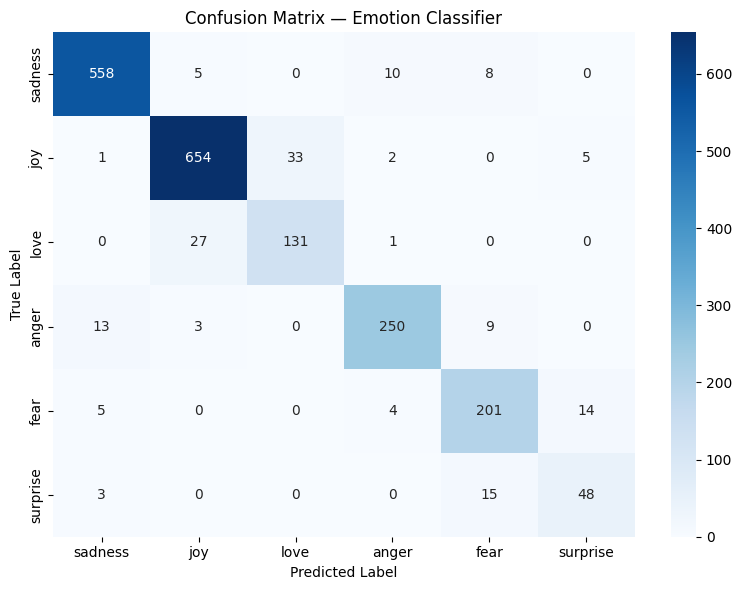

✅ Results saved to emotion_results/


In [8]:
print("📊 Evaluating on test set ...")

predictions_output = trainer.predict(datasets["test"])
logits      = predictions_output.predictions
true_labels = predictions_output.label_ids
pred_labels = np.argmax(logits, axis=-1)

label_names = [ID2LABEL[i] for i in range(len(ID2LABEL))]

acc    = accuracy_score(true_labels, pred_labels)
f1_w   = f1_score(true_labels, pred_labels, average="weighted")
f1_mac = f1_score(true_labels, pred_labels, average="macro")
report = classification_report(true_labels, pred_labels, target_names=label_names)
cm     = confusion_matrix(true_labels, pred_labels)

print(f"\n{'='*55}")
print(f"  Accuracy      : {acc:.4f}")
print(f"  F1 (weighted) : {f1_w:.4f}")
print(f"  F1 (macro)    : {f1_mac:.4f}")
print(f"{'='*55}")
print("\nClassification Report:\n")
print(report)

# ── Confusion matrix (visual) ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = "d",
    cmap       = "Blues",
    xticklabels = label_names,
    yticklabels = label_names,
)
plt.title("Confusion Matrix — Emotion Classifier")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "confusion_matrix.png"), dpi=150)
plt.show()

# ── Persist metrics ────────────────────────────────────────────────────────
metrics = {
    "accuracy"    : round(acc, 4),
    "f1_weighted" : round(f1_w, 4),
    "f1_macro"    : round(f1_mac, 4),
    "confusion_matrix": cm.tolist(),
}
with open(RESULTS_DIR / "test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
(RESULTS_DIR / "classification_report.txt").write_text(report)
print("✅ Results saved to emotion_results/")

In [9]:
class EmotionClassifier:
    """
    Production inference wrapper.
    Load once, call predict() on every user message in the chatbot pipeline.
    """

    def __init__(self, model_dir: str = str(MODEL_DIR)):
        print(f"⚙️  Loading emotion model from '{model_dir}' ...")
        self._pipe = pipeline(
            task        = "text-classification",
            model       = model_dir,
            tokenizer   = model_dir,
            top_k       = None,           # return scores for all 6 classes
            truncation  = True,
            max_length  = CONFIG["max_length"],
            device      = 0 if torch.cuda.is_available() else -1,
        )
        print("✅ Emotion classifier ready")

    def predict(self, text: str) -> Dict:
        """
        Returns
        -------
        {
          "emotion"    : "sadness",
          "confidence" : 0.94,
          "tone_hint"  : "empathetic_supportive",
          "all_scores" : {"sadness": 0.94, "joy": 0.02, ...}
        }
        """
        cleaned = EmotionDataPreprocessor.clean_text(text)
        scores  = self._pipe(cleaned)[0]
        top     = max(scores, key=lambda x: x["score"])
        return {
            "emotion"    : top["label"],
            "confidence" : round(top["score"], 4),
            "tone_hint"  : EMOTION_TONE.get(top["label"], "neutral"),
            "all_scores" : {s["label"]: round(s["score"], 4) for s in scores},
        }

    def predict_batch(self, texts: List[str]) -> List[Dict]:
        """Predict emotions for a list of texts in one pass."""
        cleaned = [EmotionDataPreprocessor.clean_text(t) for t in texts]
        batch   = self._pipe(cleaned)
        results = []
        for scores in batch:
            top = max(scores, key=lambda x: x["score"])
            results.append({
                "emotion"    : top["label"],
                "confidence" : round(top["score"], 4),
                "tone_hint"  : EMOTION_TONE.get(top["label"], "neutral"),
                "all_scores" : {s["label"]: round(s["score"], 4) for s in scores},
            })
        return results


def get_emotion_response(text: str, classifier: EmotionClassifier) -> Dict:
    """
    Chatbot pipeline helper.
    Adds crisis_flag: True when fear/sadness confidence >= 0.90,
    which triggers immediate crisis-support escalation in the chatbot.
    """
    result = classifier.predict(text)
    result["crisis_flag"] = (
        result["emotion"] in {"sadness", "fear"} and result["confidence"] >= 0.90
    )
    return result


# ── Instantiate ────────────────────────────────────────────────────────────
classifier = EmotionClassifier()

⚙️  Loading emotion model from 'emotion_model' ...


✅ Emotion classifier ready


In [11]:
test_sentences = [
    "I feel so hopeless and empty inside.",
    "Today was absolutely wonderful, I am over the moon!",
    "I am furious, this is completely unacceptable.",
    "Something feels off, I am a bit scared.",
    "I love spending time with my family so much.",
    "Wow, I did not see that coming at all!",
    "Everything is going great, I feel fantastic!",
]

print(f"{'Text':<52} {'Emotion':<10} {'Conf':>6}  {'Tone Hint':<25} {'Crisis'}")
print("-" * 110)
for text in test_sentences:
    r = get_emotion_response(text, classifier)
    print(
        f"{text[:50]:<52} "
        f"{r['emotion']:<10} "
        f"{r['confidence']:>6.2f}  "
        f"{r['tone_hint']:<25} "
        f"{'⚠️ YES' if r['crisis_flag'] else 'no'}"
    )

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Text                                                 Emotion      Conf  Tone Hint                 Crisis
--------------------------------------------------------------------------------------------------------------
I feel so hopeless and empty inside.                 sadness      1.00  empathetic_supportive     ⚠️ YES
Today was absolutely wonderful, I am over the moon   joy          1.00  celebratory_positive      no
I am furious, this is completely unacceptable.       anger        1.00  calm_de-escalating        no
Something feels off, I am a bit scared.              fear         1.00  reassuring_grounding      ⚠️ YES
I love spending time with my family so much.         joy          0.50  celebratory_positive      no
Wow, I did not see that coming at all!               joy          0.38  celebratory_positive      no
Everything is going great, I feel fantastic!         joy          1.00  celebratory_positive      no
